# Imports

In [1]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

import tensorflow as tf

from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.models import Model

from tensorflow.keras.layers import (
    GlobalAveragePooling2D,
    Dense,
    BatchNormalization,
    Dropout
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

from tensorflow.keras.optimizers import Adam

print("TensorFlow :", tf.__version__)
print("GPU :", len(tf.config.list_physical_devices("GPU")))

TensorFlow : 2.21.0
GPU : 0


## Parameters and config

In [5]:
TRAIN_DIR = "../classification/train"
VALID_DIR = "../classification/val"
TEST_DIR = "../classification/test"

IMAGE_SIZE = (224,224)
BATCH_SIZE = 32
EPOCHS = 25
LEARNING_RATE = 1e-4
MODEL_DIR = "../models"
os.makedirs(MODEL_DIR, exist_ok=True)

## Data Augmentation

In [ ]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    shear_range=0.2,
    horizontal_flip=True,
    fill_mode="nearest"
)
valid_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)
test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

## Load Data

In [8]:
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)

valid_generator = valid_datagen.flow_from_directory(
    VALID_DIR,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

NUM_CLASSES = train_generator.num_classes
print(train_generator.class_indices)

Found 1820 images belonging to 26 classes.
Found 390 images belonging to 26 classes.
Found 390 images belonging to 26 classes.
{'airplane': 0, 'bed': 1, 'bench': 2, 'bicycle': 3, 'bird': 4, 'bottle': 5, 'bowl': 6, 'bus': 7, 'cake': 8, 'car': 9, 'cat': 10, 'chair': 11, 'couch': 12, 'cow': 13, 'cup': 14, 'dog': 15, 'elephant': 16, 'horse': 17, 'motorcycle': 18, 'person': 19, 'pizza': 20, 'potted plant': 21, 'stop sign': 22, 'traffic light': 23, 'train': 24, 'truck': 25}


## Class Weights

In [9]:
labels = train_generator.classes
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(labels),
    y=labels
)
class_weights = dict(enumerate(class_weights))
print(class_weights)

{0: np.float64(1.0), 1: np.float64(1.0), 2: np.float64(1.0), 3: np.float64(1.0), 4: np.float64(1.0), 5: np.float64(1.0), 6: np.float64(1.0), 7: np.float64(1.0), 8: np.float64(1.0), 9: np.float64(1.0), 10: np.float64(1.0), 11: np.float64(1.0), 12: np.float64(1.0), 13: np.float64(1.0), 14: np.float64(1.0), 15: np.float64(1.0), 16: np.float64(1.0), 17: np.float64(1.0), 18: np.float64(1.0), 19: np.float64(1.0), 20: np.float64(1.0), 21: np.float64(1.0), 22: np.float64(1.0), 23: np.float64(1.0), 24: np.float64(1.0), 25: np.float64(1.0)}


## Load ResNet50

In [10]:
base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)
base_model.trainable = False
print("Base Model Loaded Successfully")

Base Model Loaded Successfully


## Classification Head

In [11]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dense(
    1024,
    activation="relu",
    kernel_initializer="he_normal"
)(x)
x = Dropout(0.5)(x)
x = Dense(
    512,
    activation="relu",
    kernel_initializer="he_normal"
)(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)
outputs = Dense(
    NUM_CLASSES,
    activation="softmax"
)(x)
model = Model(
    inputs=base_model.input,
    outputs=outputs
)

## Compile Model

In [12]:
model.compile(
    optimizer=Adam(
        learning_rate=LEARNING_RATE
    ),
    loss=tf.keras.losses.CategoricalCrossentropy(
        label_smoothing=0.1
    ),
    metrics=["accuracy"]
)

## Callbacks

In [13]:
checkpoint = ModelCheckpoint(
    os.path.join(
        MODEL_DIR,
        "resnet50_best.keras"
    ),
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

callbacks = [
    checkpoint,
    early_stop,
    reduce_lr
]

## Train Stage 1

In [14]:
history = model.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.0739 - loss: 4.1290
Epoch 1: val_accuracy improved from None to 0.21795, saving model to ../models\resnet50_best.keras
57/57 ━━━━━━━━━━━━━━━━━━━━ 96s 2s/step - accuracy: 0.0967 - loss: 3.8719 - val_accuracy: 0.2179 - val_loss: 2.7962 - learning_rate: 1.0000e-04
Epoch 2/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.2320 - loss: 3.1336
Epoch 2: val_accuracy improved from 0.21795 to 0.40000, saving model to ../models\resnet50_best.keras
57/57 ━━━━━━━━━━━━━━━━━━━━ 84s 1s/step - accuracy: 0.2549 - loss: 2.9960 - val_accuracy: 0.4000 - val_loss: 2.4737 - learning_rate: 1.0000e-04
Epoch 3/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3356 - loss: 2.6914
Epoch 3: val_accuracy improved from 0.40000 to 0.43077, saving model to ../models\resnet50_best.keras
57/57 ━━━━━━━━━━━━━━━━━━━━ 88s 2s/step - accuracy: 0.3670 - loss: 2.6006 - val_accuracy: 0.4308 - val_loss: 2.3515 - learning_rate: 1.0000e-04
Epoch 4/25
57/57 ━━

## Save Stage-1 Model

In [15]:
stage1_model_path = os.path.join(
    MODEL_DIR,
    "resnet50_stage1.keras"
)

model.save(stage1_model_path)

print("Stage-1 model saved successfully!")

Stage-1 model saved successfully!


## Plot Stage-1 Training

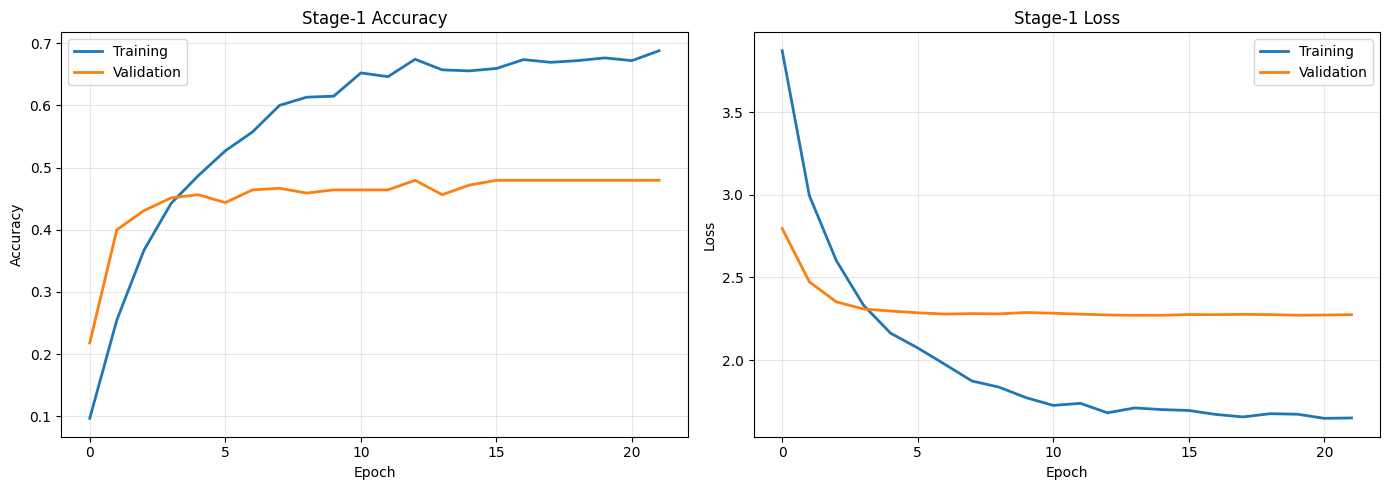

In [16]:
plt.figure(figsize=(14,5))

plt.subplot(1,2,1)

plt.plot(
    history.history["accuracy"],
    label="Training",
    linewidth=2
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation",
    linewidth=2
)

plt.title("Stage-1 Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1,2,2)

plt.plot(
    history.history["loss"],
    label="Training",
    linewidth=2
)

plt.plot(
    history.history["val_loss"],
    label="Validation",
    linewidth=2
)

plt.title("Stage-1 Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Unfreeze Top Layers

In [17]:
for layer in base_model.layers:
    layer.trainable = False

for layer in base_model.layers[-30:]:
    layer.trainable = True

print("=" * 60)
print("Trainable Layers")
print("=" * 60)

trainable_count = 0

for layer in base_model.layers:
    if layer.trainable:
        trainable_count += 1
    print(f"{layer.name:35} : {layer.trainable}")

print("\nTotal Trainable Layers:", trainable_count)

Trainable Layers
input_layer                         : False
conv1_pad                           : False
conv1_conv                          : False
conv1_bn                            : False
conv1_relu                          : False
pool1_pad                           : False
pool1_pool                          : False
conv2_block1_1_conv                 : False
conv2_block1_1_bn                   : False
conv2_block1_1_relu                 : False
conv2_block1_2_conv                 : False
conv2_block1_2_bn                   : False
conv2_block1_2_relu                 : False
conv2_block1_0_conv                 : False
conv2_block1_3_conv                 : False
conv2_block1_0_bn                   : False
conv2_block1_3_bn                   : False
conv2_block1_add                    : False
conv2_block1_out                    : False
conv2_block2_1_conv                 : False
conv2_block2_1_bn                   : False
conv2_block2_1_relu                 : False
conv2_block2_2_

## Recompile

In [18]:
model.compile(

    optimizer=Adam(
        learning_rate=1e-5
    ),
    loss=tf.keras.losses.CategoricalCrossentropy(
        label_smoothing=0.1
    ),

    metrics=["accuracy"]
)

## Fine-Tuning

In [19]:
fine_tune_epochs = 15
history_fine = model.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=fine_tune_epochs,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6129 - loss: 1.8087
Epoch 1: val_accuracy did not improve from 0.47949
57/57 ━━━━━━━━━━━━━━━━━━━━ 129s 2s/step - accuracy: 0.6275 - loss: 1.7896 - val_accuracy: 0.4641 - val_loss: 2.3188 - learning_rate: 1.0000e-05
Epoch 2/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6620 - loss: 1.6474
Epoch 2: val_accuracy improved from 0.47949 to 0.48205, saving model to ../models\resnet50_best.keras
57/57 ━━━━━━━━━━━━━━━━━━━━ 120s 2s/step - accuracy: 0.6412 - loss: 1.7266 - val_accuracy: 0.4821 - val_loss: 2.3229 - learning_rate: 1.0000e-05
Epoch 3/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6729 - loss: 1.6288
Epoch 3: val_accuracy improved from 0.48205 to 0.48462, saving model to ../models\resnet50_best.keras

Epoch 3: ReduceLROnPlateau reducing learning rate to 1.9999999494757505e-06.
57/57 ━━━━━━━━━━━━━━━━━━━━ 111s 2s/step - accuracy: 0.6566 - loss: 1.6610 - val_accuracy: 0.4846 - val_loss: 2.3181 - learning_rat

## Save Final Model

In [20]:
final_model_path = os.path.join(
    MODEL_DIR,
    "resnet50_final.keras"
)
model.save(final_model_path)
print("Final model saved successfully!")

Final model saved successfully!


## Evaluate

In [21]:
loss, accuracy = model.evaluate(
    test_generator,
    verbose=1
)
print("="*50)
print(f"Test Accuracy : {accuracy*100:.2f}%")
print(f"Test Loss     : {loss:.4f}")
print("="*50)

13/13 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.4641 - loss: 2.3873
Test Accuracy : 46.41%
Test Loss     : 2.3873


## Predictions

In [22]:
test_generator.reset()
predictions = model.predict(
    test_generator,
    verbose=1
)
y_pred = np.argmax(predictions, axis=1)
y_true = test_generator.classes
class_names = list(test_generator.class_indices.keys())

13/13 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step


## Confusion Matrix

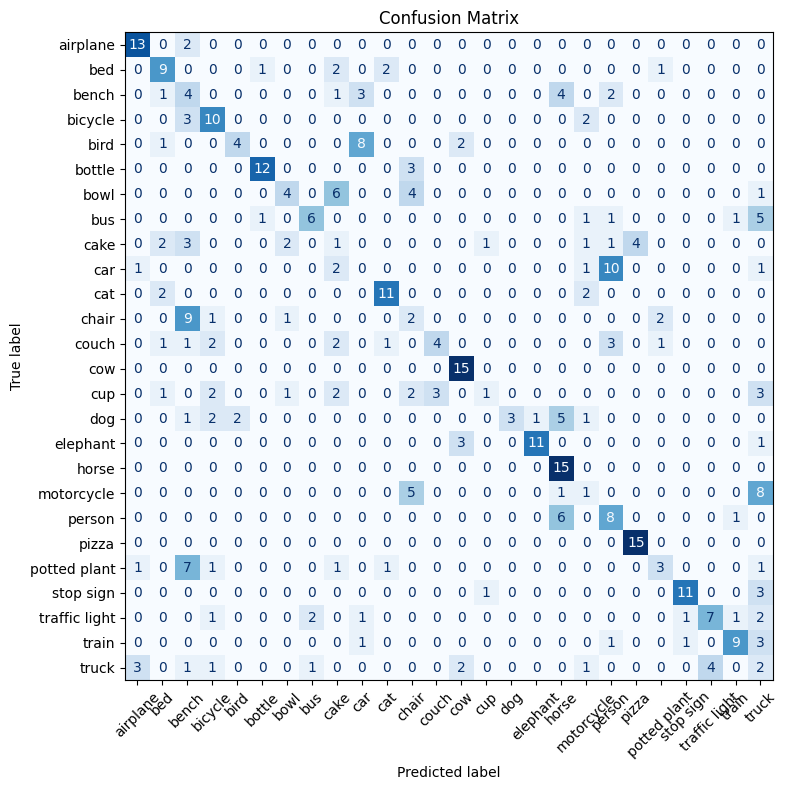

In [23]:
cm = confusion_matrix(
    y_true,
    y_pred
)

fig, ax = plt.subplots(figsize=(10,8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(
    cmap="Blues",
    ax=ax,
    colorbar=False,
    xticks_rotation=45
)

plt.title("Confusion Matrix")

plt.tight_layout()

plt.show()

## Classification Report

In [24]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

               precision    recall  f1-score   support

     airplane       0.72      0.87      0.79        15
          bed       0.53      0.60      0.56        15
        bench       0.13      0.27      0.17        15
      bicycle       0.50      0.67      0.57        15
         bird       0.67      0.27      0.38        15
       bottle       0.86      0.80      0.83        15
         bowl       0.50      0.27      0.35        15
          bus       0.67      0.40      0.50        15
         cake       0.06      0.07      0.06        15
          car       0.00      0.00      0.00        15
          cat       0.73      0.73      0.73        15
        chair       0.12      0.13      0.13        15
        couch       0.57      0.27      0.36        15
          cow       0.68      1.00      0.81        15
          cup       0.33      0.07      0.11        15
          dog       1.00      0.20      0.33        15
     elephant       0.92      0.73      0.81        15
        h

## Fine-Tuning Curves

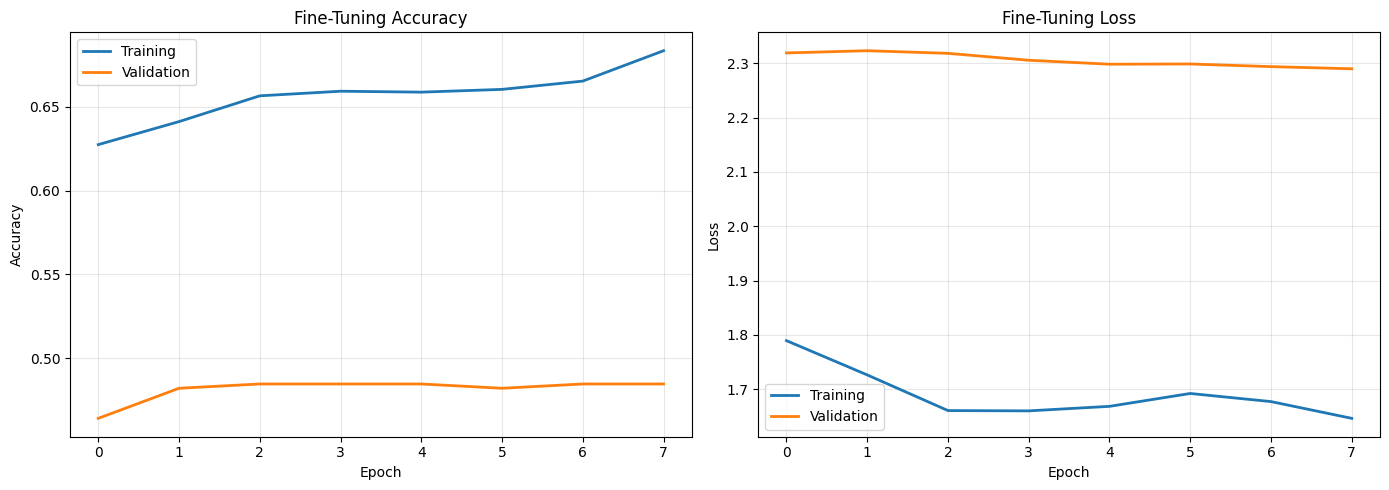

In [25]:
plt.figure(figsize=(14,5))

plt.subplot(1,2,1)

plt.plot(
    history_fine.history["accuracy"],
    linewidth=2,
    label="Training"
)

plt.plot(
    history_fine.history["val_accuracy"],
    linewidth=2,
    label="Validation"
)

plt.title("Fine-Tuning Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1,2,2)

plt.plot(
    history_fine.history["loss"],
    linewidth=2,
    label="Training"
)

plt.plot(
    history_fine.history["val_loss"],
    linewidth=2,
    label="Validation"
)

plt.title("Fine-Tuning Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

## Training Summary

In [26]:
print("="*65)
print("SmartVision V2 - ResNet50 Training Complete")
print("="*65)

print(f"Number of Classes : {NUM_CLASSES}")
print(f"Image Size        : {IMAGE_SIZE}")
print(f"Batch Size        : {BATCH_SIZE}")

print(f"\nFinal Test Accuracy : {accuracy*100:.2f}%")
print(f"Final Test Loss     : {loss:.4f}")

print("\nSaved Models")
print(f"Best Model   : {os.path.join(MODEL_DIR,'resnet50_best.keras')}")
print(f"Stage-1 Model: {os.path.join(MODEL_DIR,'resnet50_stage1.keras')}")
print(f"Final Model  : {os.path.join(MODEL_DIR,'resnet50_final.keras')}")

print("="*65)

SmartVision V2 - ResNet50 Training Complete
Number of Classes : 26
Image Size        : (224, 224)
Batch Size        : 32

Final Test Accuracy : 46.41%
Final Test Loss     : 2.3873

Saved Models
Best Model   : ../models\resnet50_best.keras
Stage-1 Model: ../models\resnet50_stage1.keras
Final Model  : ../models\resnet50_final.keras
